# 01 — Análise exploratória e entendimento do problema

**Tech Challenge — Fase 3 · Predição e Inteligência Analítica para Alfabetização no Brasil**

Este notebook abre o projeto. Ele responde a três perguntas antes de qualquer modelo:

1. Como os dados se comportam — distribuições, ausências, relações;
2. Que hipóteses analíticas valem a pena testar;
3. Que decisões de modelagem esses achados impõem.

A base vem da **camada Gold construída na Fase 2**
([repositório](https://github.com/Luodev/1IAST-Fase2)), reconstruída localmente
pelo módulo `src/data/gold_loader.py`, e é enriquecida com dados do IBGE.

In [1]:
import sys, warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))   # torna o pacote `src` importável
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)

## 1. Reconstrução da camada Gold

A Fase 2 entregou uma pipeline Medalhão (Bronze → Silver → Gold) em AWS Glue.
Para a Fase 3 ser reproduzível em qualquer máquina, `gold_loader.py` reexecuta a
mesma lógica em pandas sobre os CSVs originais, gravando um data lake local com
o mesmo particionamento Hive-style (`ano=YYYY`).

In [2]:
from src.data.gold_loader import construir_lake, ler_gold

resumo = construir_lake(forcar=True)
pd.Series(resumo["gold"], name="registros").to_frame()

,registros
alfabetizacao_por_municipio,10896
evolucao_temporal,49
ranking_municipios,10896
comparacao_metas_nacionais,50


In [3]:
gold_municipio = ler_gold("alfabetizacao_por_municipio")
print("Visão Gold — alfabetizacao_por_municipio:", gold_municipio.shape)
gold_municipio.head()

Visão Gold — alfabetizacao_por_municipio: (10896, 14)


,id_municipio,serie,rede,taxa_alfabetizacao,media_portugues,meta_2024,meta_2025,meta_2030,nivel_alfabetizacao,percentual_participacao,gap_meta_2025,status_meta_2025,_gold_processed_at,ano
0,1100031,2,municipal,69.10,767.88,70.85,72.53,80.0,3,90.48,-3.43,NAO_ATINGIU,20260912_003033,2023
1,1100072,2,municipal,58.20,747.89,61.82,65.31,80.0,2,92.25,-7.11,NAO_ATINGIU,20260912_003033,2023
2,1101609,2,municipal,50.70,745.68,55.53,60.25,80.0,2,95.00,-9.55,NAO_ATINGIU,20260912_003033,2023
3,1101807,2,municipal,55.69,752.37,59.72,63.63,80.0,2,83.15,-7.94,NAO_ATINGIU,20260912_003033,2023
4,1302900,2,municipal,53.17,731.07,57.61,61.93,80.0,2,78.48,-8.76,NAO_ATINGIU,20260912_003033,2023


## 2. A ABT e a nota metodológica sobre o grão

O enunciado pede um modelo que preveja **se um aluno será alfabetizado ou não**.
A camada Gold, porém, é agregada: o menor grão publicado pelo INEP para o
Indicador Criança Alfabetizada é *município × rede × ano* — não existe microdado
por aluno.

Adotamos então o grão mais fino disponível e mantemos a leitura no aluno:

- cada linha é o **aluno típico** de um município da rede municipal;
- o alvo vale 1 quando o município alfabetiza pelo menos **60%** dos alunos —
  patamar do resultado nacional de 2024 (59,2%) e da meta nacional daquele ano
  (59,9%);
- a probabilidade prevista é **calibrada** e conferida contra a taxa real do
  município (notebook 02), o que autoriza lê-la como a chance de um aluno
  daquele município terminar o 2º ano alfabetizado.

A limitação está registrada no README e no relatório técnico.

In [4]:
from src.config import ANO_ALVO, ANO_BASE, CORTE_ALFABETIZACAO
from src.data.build_abt import construir_abt

abt = construir_abt()
print(f"ABT: {abt.shape[0]} municípios x {abt.shape[1]} colunas")
print(f"Alvo: taxa de {ANO_ALVO} >= {CORTE_ALFABETIZACAO:.0f}%")
print(f"Positivos: {abt['alfabetizado'].mean():.2%}")
abt.head()

ABT: 5396 municípios x 35 colunas
Alvo: taxa de 2024 >= 60%
Positivos: 56.95%


,id_municipio,taxa_alvo,alfabetizado,atinge_meta_2025,taxa_alf_2023,media_portugues_2023,nivel_alfabetizacao_2023,participacao_2023,ranking_uf_2023,municipios_na_uf_2023,percentil_uf_2023,taxa_estadual_2023,taxa_privada_2023,meta_2024,meta_2025,meta_2030,inclinacao_meta_anual,nome_municipio,sigla_uf,regiao,regiao_intermediaria,populacao_2022,log_populacao,area_km2,densidade_hab_km2,taxa_alfabetizacao_15mais,pib_per_capita,log_pib_per_capita,porte_municipio,gap_2023_para_meta_2024,gap_2023_para_meta_2025,dif_municipal_estadual_2023,dif_municipal_privada_2023,dif_crianca_adulto,porte_relativo_na_uf
0,3532868,25.00,0,0,40.00,741.72,0,95.24,600,627,0.0431,NaN,NaN,46.27,52.66,80.0,5.468,Nova Castilho,SP,Sudeste,Araçatuba,1062.0,6.968850,183.396,5.79,95.90,57123.35,10.952986,Ate 5 mil,-6.27,-12.66,NaN,NaN,-55.90,0.0016
1,1704600,6.25,0,0,50.00,740.70,1,84.21,32,139,0.7754,NaN,50.00,54.93,59.77,80.0,4.046,Chapada de Areia,TO,Norte,Palmas,1501.0,7.314553,658.564,2.28,84.93,26531.65,10.186131,Ate 5 mil,-4.93,-9.77,NaN,0.00,-34.93,0.0216
2,2406155,33.33,0,0,54.55,729.69,<NA>,NaN,23,166,0.8667,NaN,54.55,NaN,41.43,80.0,7.714,Jundiá,RN,Nordeste,Natal,3739.0,8.226841,44.641,83.76,75.47,11272.27,9.330190,Ate 5 mil,NaN,13.12,NaN,0.00,-20.92,0.1758
3,2406205,11.65,0,0,13.11,694.43,<NA>,NaN,163,166,0.0182,41.67,24.79,NaN,19.26,80.0,12.148,Lagoa d'Anta,RN,Nordeste,Natal,6654.0,8.803124,105.652,62.98,75.62,10645.78,9.273013,5-10 mil,NaN,-6.15,-28.56,-11.68,-62.51,0.4485
4,1710706,18.09,0,0,32.53,725.91,0,95.31,85,139,0.3913,NaN,32.53,39.48,46.88,80.0,6.624,Itaguatins,TO,Norte,Araguaína,5172.0,8.551208,730.163,7.08,82.38,15972.74,9.678701,5-10 mil,-6.95,-14.35,NaN,0.00,-49.85,0.5971


In [5]:
# Qualidade: o que falta e o quanto falta.
faltantes = (abt.isna().sum().loc[lambda s: s > 0]
             .sort_values(ascending=False).to_frame("nulos"))
faltantes["percentual"] = (faltantes["nulos"] / len(abt) * 100).round(1)
faltantes

,nulos,percentual
taxa_estadual_2023,4335,80.3
dif_municipal_estadual_2023,4335,80.3
dif_municipal_privada_2023,546,10.1
taxa_privada_2023,546,10.1
nivel_alfabetizacao_2023,164,3.0
participacao_2023,164,3.0
meta_2024,164,3.0
gap_2023_para_meta_2024,164,3.0
inclinacao_meta_anual,94,1.7
meta_2030,94,1.7


**Leitura das ausências.** `taxa_estadual_2023` falta em ~80% dos municípios, e
isso não é erro de coleta: a maior parte das cidades brasileiras simplesmente não
tem rede estadual oferecendo o 2º ano do fundamental. A ausência é informação
sobre o território. Por isso o pré-processamento usa `add_indicator=True`, que
cria uma coluna sinalizando "este município não tem rede estadual" em vez de
fingir que o valor existe.

## 3. Distribuição do alvo

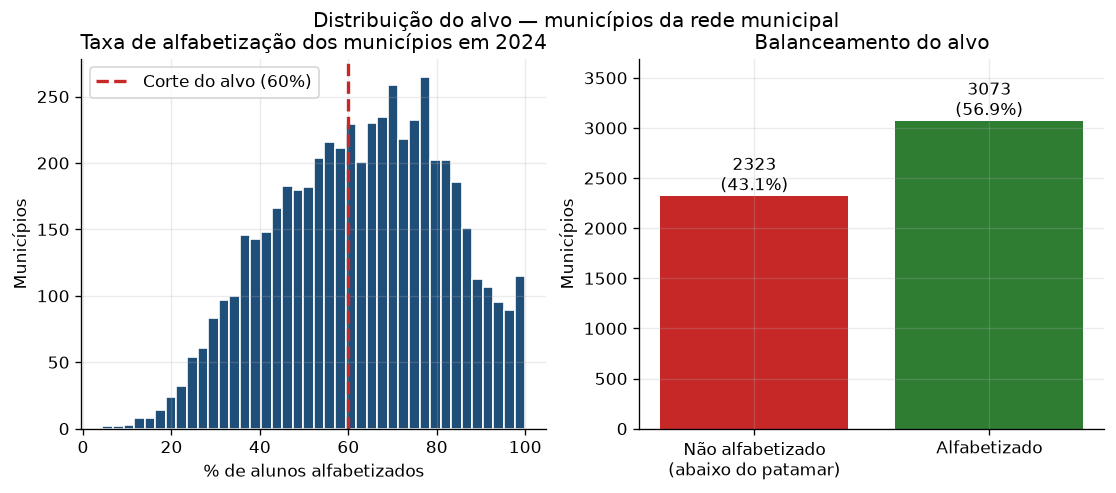

,taxa de alfabetização em 2024
count,5396.00
mean,62.87
std,19.31
min,4.40
25%,48.40
50%,64.15
75%,77.62
max,100.00


In [6]:
from src.visualization import plots
from IPython.display import Image, display

display(Image(filename=str(plots.distribuicao_alvo(abt, CORTE_ALFABETIZACAO))))
abt["taxa_alvo"].describe().round(2).to_frame("taxa de alfabetização em 2024")

O corte em 60% divide a base em **57% de municípios alfabetizados** contra 43%
abaixo do patamar. Classes equilibradas evitam o problema clássico de métricas
infladas: com 90% de uma classe, um modelo que chuta sempre a majoritária teria
90% de acurácia e nenhuma utilidade.

A distribuição também mostra a dispersão enorme do indicador — de 4% a 100%. O
Brasil não tem *um* problema de alfabetização, tem realidades muito distintas
convivendo no mesmo sistema.

## 4. Desigualdade territorial

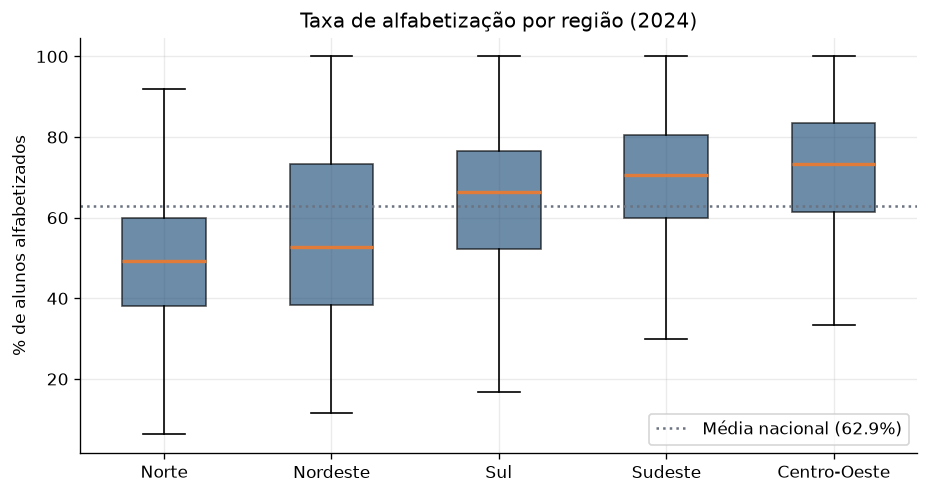

,municipios,taxa_media,taxa_mediana,perc_alfabetizados
regiao,,,,
Norte,413,49.742,49.280,0.249
Nordeste,1779,56.335,52.630,0.394
Sul,1130,63.921,66.265,0.619
Sudeste,1612,70.000,70.600,0.750
Centro-Oeste,462,72.347,73.345,0.781


In [7]:
display(Image(filename=str(plots.taxa_por_regiao(abt))))

(abt.groupby("regiao")
    .agg(municipios=("id_municipio", "size"),
         taxa_media=("taxa_alvo", "mean"),
         taxa_mediana=("taxa_alvo", "median"),
         perc_alfabetizados=("alfabetizado", "mean"))
    .round(3).sort_values("taxa_media"))

**Hipótese 1 — o território importa.** A diferença entre a mediana do Nordeste e
a do Sul passa de 20 pontos percentuais. Se região e UF carregarem esse sinal, é
esperado que apareçam entre as variáveis mais influentes do modelo — e é o que
acontece no notebook 02.

Mas há um alerta embutido: um modelo que aprende sobretudo "em que estado o
município fica" generaliza mal para um estado que não viu no treino. O notebook 02
testa exatamente isso com a validação por região.

## 5. Persistência do desempenho entre 2023 e 2024

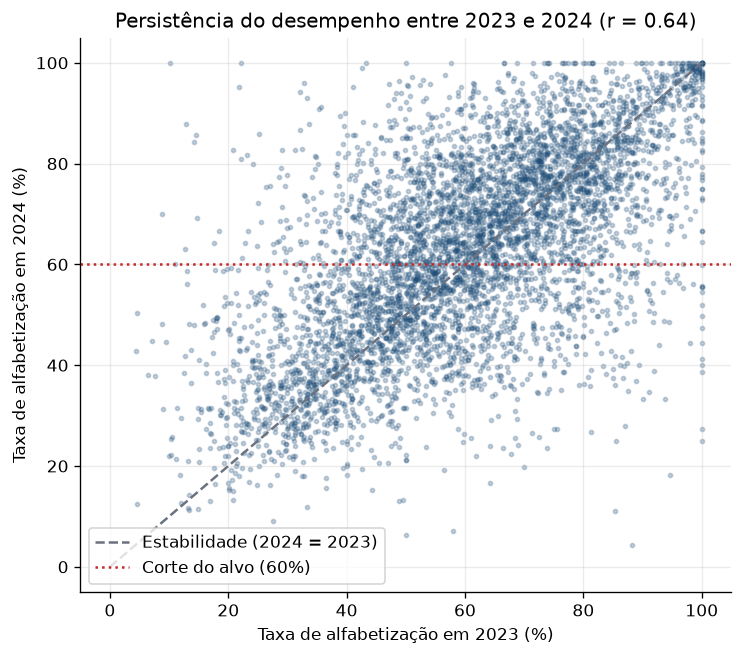

,valor
correlação 2023 x 2024,0.636
variação média (p.p.),2.671
desvio da variação (p.p.),16.682
municípios que pioraram,0.417


In [8]:
display(Image(filename=str(plots.dispersao_historico(abt, CORTE_ALFABETIZACAO))))

variacao = abt["taxa_alvo"] - abt["taxa_alf_2023"]
pd.Series({
    "correlação 2023 x 2024": abt["taxa_alf_2023"].corr(abt["taxa_alvo"]),
    "variação média (p.p.)": variacao.mean(),
    "desvio da variação (p.p.)": variacao.std(),
    "municípios que pioraram": (variacao < 0).mean(),
}).round(3).to_frame("valor")

**Hipótese 2 — desempenho educacional é persistente, mas não determinístico.**
A correlação de 0,64 entre 2023 e 2024 confirma que o passado prevê o futuro; a
dispersão em torno da diagonal mostra que há espaço real para mudança — e é essa
margem que a política pública tenta ocupar.

O desvio-padrão da variação anual (16,7 p.p.) é grande, e traz uma consequência
direta para o notebook 04: **extrapolar a variação de um único ano por seis anos
amplificaria ruído**. Por isso a projeção usa encolhimento em direção à média da
UF e amortecimento ao longo do horizonte.

## 6. Contexto socioeconômico (enriquecimento IBGE)

Três fontes externas entram na base: hierarquia territorial (API de Localidades),
população, área e densidade (Censo 2022, tabela 4714), alfabetização da população
de 15 anos ou mais (Censo 2022, tabela 9543) e PIB municipal (tabela 5938).

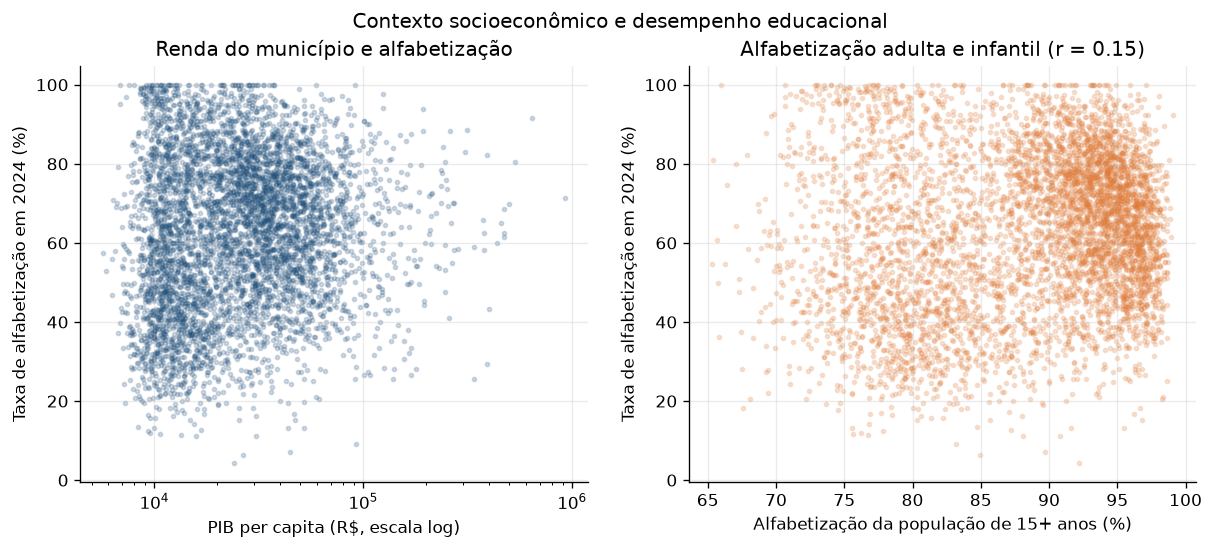

,pib_per_capita,populacao_2022,densidade_hab_km2,taxa_alfabetizacao_15mais
count,5396.00,5396.00,5396.00,5396.00
mean,34378.04,36616.55,118.26,88.16
std,39815.20,206187.59,602.76,7.59
min,5697.28,924.00,0.15,65.32
25%,13526.42,5362.25,11.57,81.95
50%,24471.97,11219.00,24.78,90.60
75%,41435.61,24742.25,55.07,94.44
max,919482.37,11451999.00,13416.81,99.10


In [9]:
display(Image(filename=str(plots.socioeconomico_vs_alfabetizacao(abt))))

abt[["pib_per_capita", "populacao_2022", "densidade_hab_km2",
     "taxa_alfabetizacao_15mais"]].describe().round(2)

**Hipótese 3 — o capital educacional da família pesa mais que a renda.** A
alfabetização adulta do município correlaciona melhor com o resultado das
crianças do que o PIB per capita. Faz sentido: renda municipal alta pode vir de
royalties ou de uma única planta industrial sem chegar às famílias, enquanto uma
população adulta alfabetizada significa lares onde se lê com a criança.

A variável derivada `dif_crianca_adulto` isola essa comparação — quanto o
desempenho infantil está acima ou abaixo do que o contexto adulto faria esperar.

## 7. Correlações e multicolinearidade

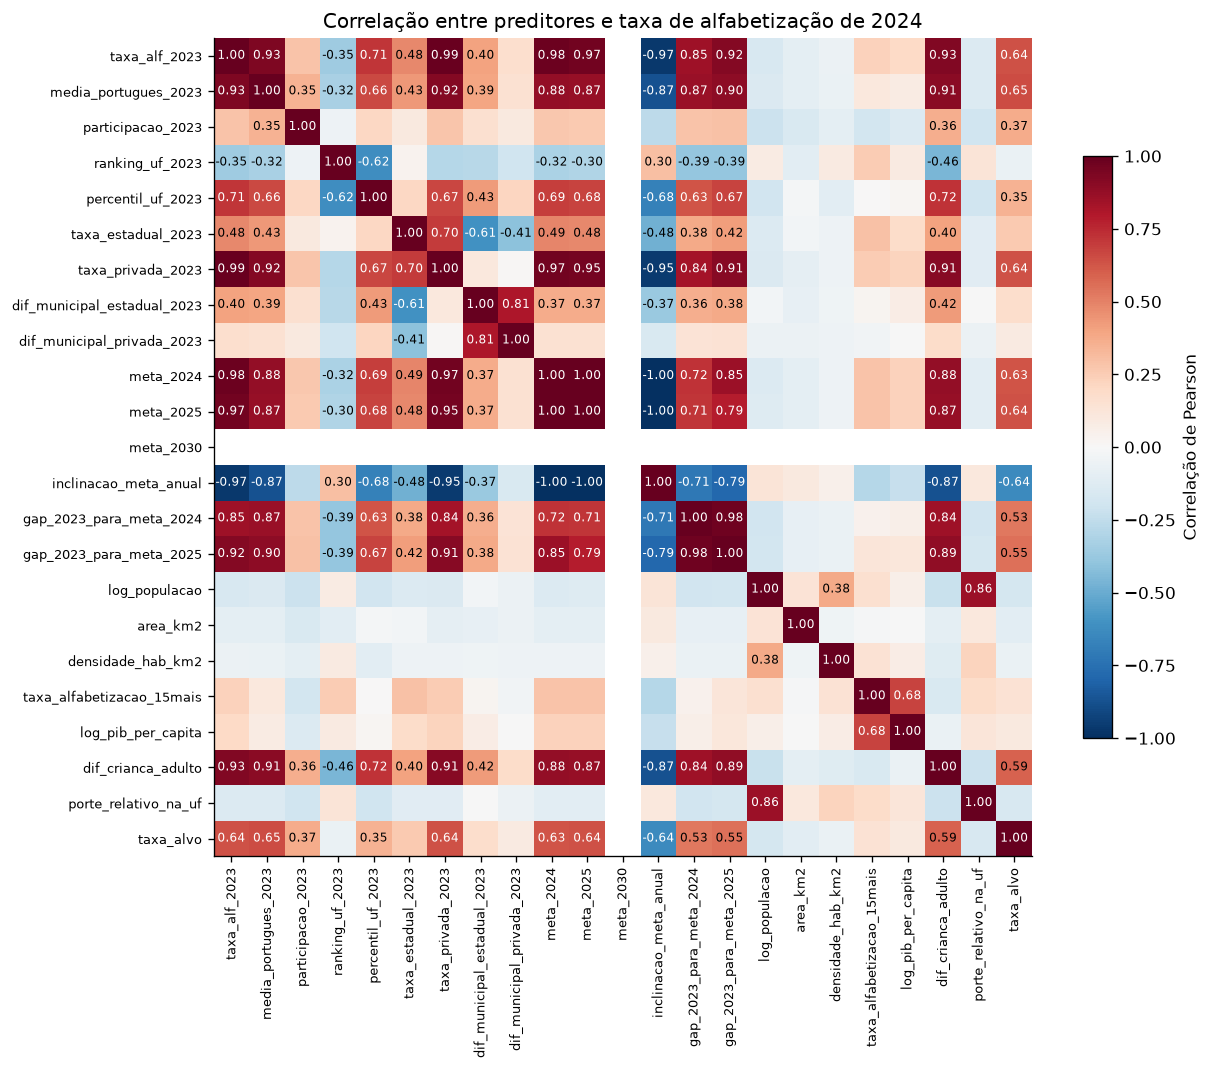

In [10]:
from src.preprocessing.features import NUMERICAS_CANDIDATAS

display(Image(filename=str(plots.correlacoes(abt, NUMERICAS_CANDIDATAS))))

In [11]:
from src.data.build_abt import analisar_redundancia

redundantes = analisar_redundancia(NUMERICAS_CANDIDATAS, abt, limite=0.95)
print("Variáveis constantes:", redundantes.attrs["constantes"])
redundantes

Variáveis constantes: ['meta_2030']


,variavel_a,variavel_b,correlacao
0,meta_2025,inclinacao_meta_anual,1.0000
1,meta_2024,meta_2025,0.9995
2,meta_2024,inclinacao_meta_anual,0.9995
3,taxa_alf_2023,taxa_privada_2023,0.9872
4,taxa_alf_2023,meta_2024,0.9787
5,gap_2023_para_meta_2024,gap_2023_para_meta_2025,0.9754
6,taxa_privada_2023,meta_2024,0.9675
7,taxa_alf_2023,meta_2025,0.9661
8,taxa_alf_2023,inclinacao_meta_anual,0.9661
9,taxa_privada_2023,inclinacao_meta_anual,0.9542


**Achado que muda a modelagem.** Vários candidatos medem a mesma coisa:

- `meta_2030` é **constante** (80% para todos os municípios);
- `inclinacao_meta_anual` tem correlação **−1,000** com `meta_2025` — ela é
  literalmente `(80 − meta_2025) / 5`;
- `meta_2024` e `meta_2025` têm correlação **1,000** entre si e **0,97** com
  `taxa_alf_2023`. As metas municipais do INEP são calculadas a partir da linha
  de base de 2023, então carregam quase a mesma informação que o resultado
  daquele ano;
- `taxa_privada_2023` tem correlação **0,987** com a taxa municipal — porque,
  em municípios sem rede privada de 2º ano, a base repete o valor da rede
  municipal na linha da rede privada. É artefato de preenchimento.

Multicolinearidade não derruba a acurácia, mas destrói a interpretação: a
importância se reparte arbitrariamente entre variáveis sinônimas e nenhuma
aparece como relevante. Como metade da entrega deste projeto é explicar *por que*
um município foi classificado como prioritário, a poda é obrigatória. O critério
e a lista final estão em `src/preprocessing/features.py`.

In [12]:
from src.preprocessing.features import (
    FEATURES, NUMERICAS, REMOVIDAS_POR_REDUNDANCIA, descrever,
)

print("Removidas por redundância:", REMOVIDAS_POR_REDUNDANCIA)
print(f"\nPreditores finais: {len(FEATURES)}")
pd.DataFrame({"variavel": FEATURES, "descricao": [descrever(c) for c in FEATURES]})

Removidas por redundância: ['meta_2024', 'meta_2025', 'meta_2030', 'inclinacao_meta_anual', 'taxa_privada_2023', 'gap_2023_para_meta_2024']

Preditores finais: 20


,variavel,descricao
0,taxa_alf_2023,Taxa de alfabetização da rede municipal em 202...
1,media_portugues_2023,Proficiência média em Português em 2023 (ponto...
2,participacao_2023,Participação dos alunos na avaliação de 2023 (%)
3,ranking_uf_2023,Posição do município no ranking da UF em 2023
4,percentil_uf_2023,Percentil do município dentro da UF em 2023
5,taxa_estadual_2023,Taxa de alfabetização da rede estadual local e...
6,dif_municipal_estadual_2023,Diferença entre rede municipal e estadual em 2...
7,dif_municipal_privada_2023,Diferença entre rede municipal e privada em 20...
8,gap_2023_para_meta_2025,Distância entre o resultado de 2023 e a meta d...
9,log_populacao,Log da população residente (Censo 2022)


## 8. Verificação anti-vazamento

O alvo deriva da taxa de 2024. Nenhuma medida daquela mesma avaliação pode entrar
como preditor. A regra é testada por código, não prometida em texto.

In [13]:
from src.data.build_abt import validar_ausencia_de_vazamento

validar_ausencia_de_vazamento(FEATURES, abt)

{'preditores_avaliados': 20,
 'colunas_proibidas_encontradas': 0,
 'maior_correlacao_com_alvo': 0.651,
 'variavel_mais_correlacionada': 'media_portugues_2023'}

A checagem confirma duas coisas: nenhuma coluna proibida está entre os preditores,
e nenhuma variável tem correlação quase perfeita com o alvo. A mais correlacionada
é a proficiência em Português de **2023** (0,65) — histórico legítimo, medido um
ano antes do resultado que queremos prever.

## 9. Síntese — o que a exploração decidiu

| Achado | Decisão de modelagem |
|---|---|
| Alvo equilibrado no corte de 60% | Manter acurácia e F1 como métricas legíveis, com ROC AUC de referência |
| Ausência de rede estadual é característica do território | Imputação com `add_indicator=True` |
| Forte desigualdade regional | Incluir UF e região, e validar deixando uma região de fora |
| Variação anual muito dispersa (σ = 16,7 p.p.) | Projeção com encolhimento e amortecimento (notebook 04) |
| Alfabetização adulta explica mais que renda | Manter `taxa_alfabetizacao_15mais` e `dif_crianca_adulto` |
| Metas do INEP são função da linha de base | Podar as metas e manter o resíduo `gap_2023_para_meta_2025` |
| `taxa_privada_2023` é cópia da municipal | Remover — artefato de preenchimento da base |

Próximo notebook: **02 — modelagem supervisionada**.